# 01 - Analyse Exploratoire des Données (EDA)

**Objectif** : Comprendre la structure, la distribution et les relations dans nos données agricoles camerounaises.

**Dataset principal** : `CMR DS10 ML training set.csv` (6000 observations)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
pd.set_option('display.max_columns', None)

%matplotlib inline

## 1. Chargement des données

In [2]:
df = pd.read_csv('../data/raw/CMR DS10 ML training set.csv')
print(f"Shape: {df.shape}")
print(f"Période: {df['annee'].min()} - {df['annee'].max()}")
df.head()

Shape: (6000, 24)
Période: 2000 - 2024


,annee,region,culture,saison,temperature_C,precipitations_mm,humidite_pct,rayonnement_MJm2,etp_mmd,co2_ppm,usage_terres_pct,stress_ecologique_idx,type_sol,ph_sol,matiere_organique_pct,N_kgha,P_kgha,K_kgha,irrigation,pratique_agricole,altitude_m,superficie_ha,rendement_tha,production_t
0,2004,Extrême-Nord,mil,grande_saison_pluies,40.57,748.77,20.15,17.77,4.79,392.51,36.15,41.91,sableux,5.70,1.21,17.27,16.72,41.37,goutte-à-goutte,traditionnelle,85.7,0.86,0.92,0.79
1,2014,Est,bananier,saison_sèche,24.48,1622.81,79.19,18.33,4.74,417.07,83.56,19.15,alluvial,5.77,2.87,239.41,57.07,230.89,non_irriguée,améliorée,661.6,1.67,11.58,19.34
2,2000,Centre,tomate,grande_saison_pluies,22.24,1570.80,69.13,15.90,2.07,371.47,62.59,29.29,ferrallitique,6.49,2.45,88.98,85.58,155.29,non_irriguée,améliorée,779.0,0.66,9.30,6.14
3,2003,Sud,palmier_à_huile,saison_sèche,29.89,1827.40,75.02,19.87,5.50,390.29,36.84,22.80,ferrallitique,5.37,4.90,91.08,43.39,216.16,aspersion,améliorée,780.6,1.97,12.33,24.29
4,2019,Centre,maïs,saison_sèche,22.64,1439.14,87.10,18.41,3.64,433.68,54.83,50.27,alluvial,6.58,2.35,87.50,51.40,59.77,aspersion,améliorée,661.9,4.39,1.58,6.94


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   annee                  6000 non-null   int64  
 1   region                 6000 non-null   str    
 2   culture                6000 non-null   str    
 3   saison                 6000 non-null   str    
 4   temperature_C          6000 non-null   float64
 5   precipitations_mm      6000 non-null   float64
 6   humidite_pct           6000 non-null   float64
 7   rayonnement_MJm2       6000 non-null   float64
 8   etp_mmd                6000 non-null   float64
 9   co2_ppm                6000 non-null   float64
 10  usage_terres_pct       6000 non-null   float64
 11  stress_ecologique_idx  6000 non-null   float64
 12  type_sol               6000 non-null   str    
 13  ph_sol                 6000 non-null   float64
 14  matiere_organique_pct  6000 non-null   float64
 15  N_kgha         

In [4]:
df.describe()

,annee,temperature_C,precipitations_mm,humidite_pct,rayonnement_MJm2,etp_mmd,co2_ppm,usage_terres_pct,stress_ecologique_idx,ph_sol,matiere_organique_pct,N_kgha,P_kgha,K_kgha,altitude_m,superficie_ha,rendement_tha,production_t
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2012.008167,25.220273,1666.193972,70.938068,18.027367,4.424988,407.564708,55.167558,37.853033,5.912545,3.002880,89.864712,42.598725,131.024810,736.806433,2.603238,5.489283,14.479803
std,7.222151,5.803445,701.453064,18.882140,3.983532,1.082002,17.138148,17.791413,13.883386,0.517168,1.190731,49.442557,17.550785,76.337694,574.880924,1.797054,6.594730,23.461871
min,2000.000000,8.000000,200.000000,20.000000,8.000000,1.000000,370.150000,5.000000,0.000000,4.000000,0.300000,5.000000,5.000000,10.000000,0.000000,0.100000,0.060000,0.010000
25%,2006.000000,21.770000,1281.152500,61.227500,15.270000,3.690000,392.940000,43.097500,28.390000,5.580000,2.200000,60.100000,29.670000,74.742500,317.900000,1.150000,0.780000,1.290000
50%,2012.000000,24.800000,1606.635000,76.945000,17.995000,4.430000,407.775000,55.335000,37.785000,5.930000,3.010000,85.600000,40.435000,109.710000,596.000000,2.510000,1.880000,3.840000
75%,2018.000000,27.720000,1940.437500,84.850000,20.740000,5.140000,421.895000,67.210000,47.510000,6.270000,3.790000,111.542500,53.377500,174.617500,1038.925000,3.800000,8.750000,17.337500
max,2024.000000,45.000000,4000.000000,100.000000,30.000000,8.660000,446.700000,100.000000,84.280000,7.600000,7.600000,350.000000,115.400000,465.140000,2970.800000,9.830000,39.890000,222.970000


## 2. Valeurs manquantes et doublons

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0])
print(f"\nDoublons: {df.duplicated().sum()}")

Empty DataFrame
Columns: [count, pct]
Index: []

Doublons: 0


## 3. Distribution de la variable cible (rendement_tha)

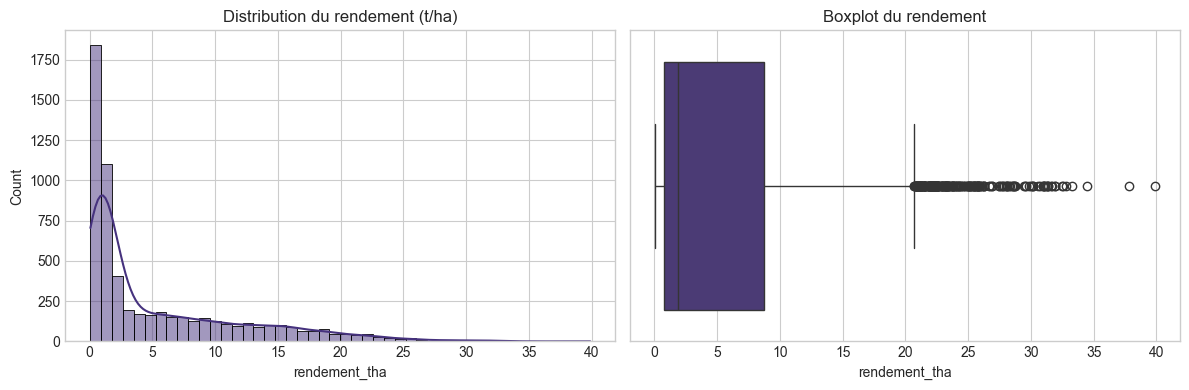

Moyenne: 5.49 t/ha
Médiane: 1.88 t/ha
Skewness: 1.49


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['rendement_tha'], kde=True, ax=axes[0])
axes[0].set_title('Distribution du rendement (t/ha)')

sns.boxplot(x=df['rendement_tha'], ax=axes[1])
axes[1].set_title('Boxplot du rendement')

plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Moyenne: {df['rendement_tha'].mean():.2f} t/ha")
print(f"Médiane: {df['rendement_tha'].median():.2f} t/ha")
print(f"Skewness: {df['rendement_tha'].skew():.2f}")

## 4. Analyse par variables catégorielles

In [7]:
cat_cols = ['region', 'culture', 'saison', 'type_sol', 'irrigation', 'pratique_agricole']

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} valeurs uniques")
    print(df[col].value_counts().head())


region: 10 valeurs uniques
region
Est             637
Sud             622
Centre          615
Sud-Ouest       615
Extrême-Nord    603
Name: count, dtype: int64

culture: 24 valeurs uniques
culture
maïs               547
palmier_à_huile    513
bananier           460
cacaotier          420
ananas             404
Name: count, dtype: int64

saison: 4 valeurs uniques
saison
petite_saison_sèche     1532
saison_sèche            1508
petite_saison_pluies    1485
grande_saison_pluies    1475
Name: count, dtype: int64

type_sol: 16 valeurs uniques
type_sol
ferrallitique    1024
alluvial          770
hydromorphe       677
vertisol          422
sableux           400
Name: count, dtype: int64

irrigation: 5 valeurs uniques
irrigation
gravitaire         1231
pluviale           1206
non_irriguée       1204
goutte-à-goutte    1186
aspersion          1173
Name: count, dtype: int64

pratique_agricole: 5 valeurs uniques
pratique_agricole
biologique         1227
traditionnelle     1217
améliorée         

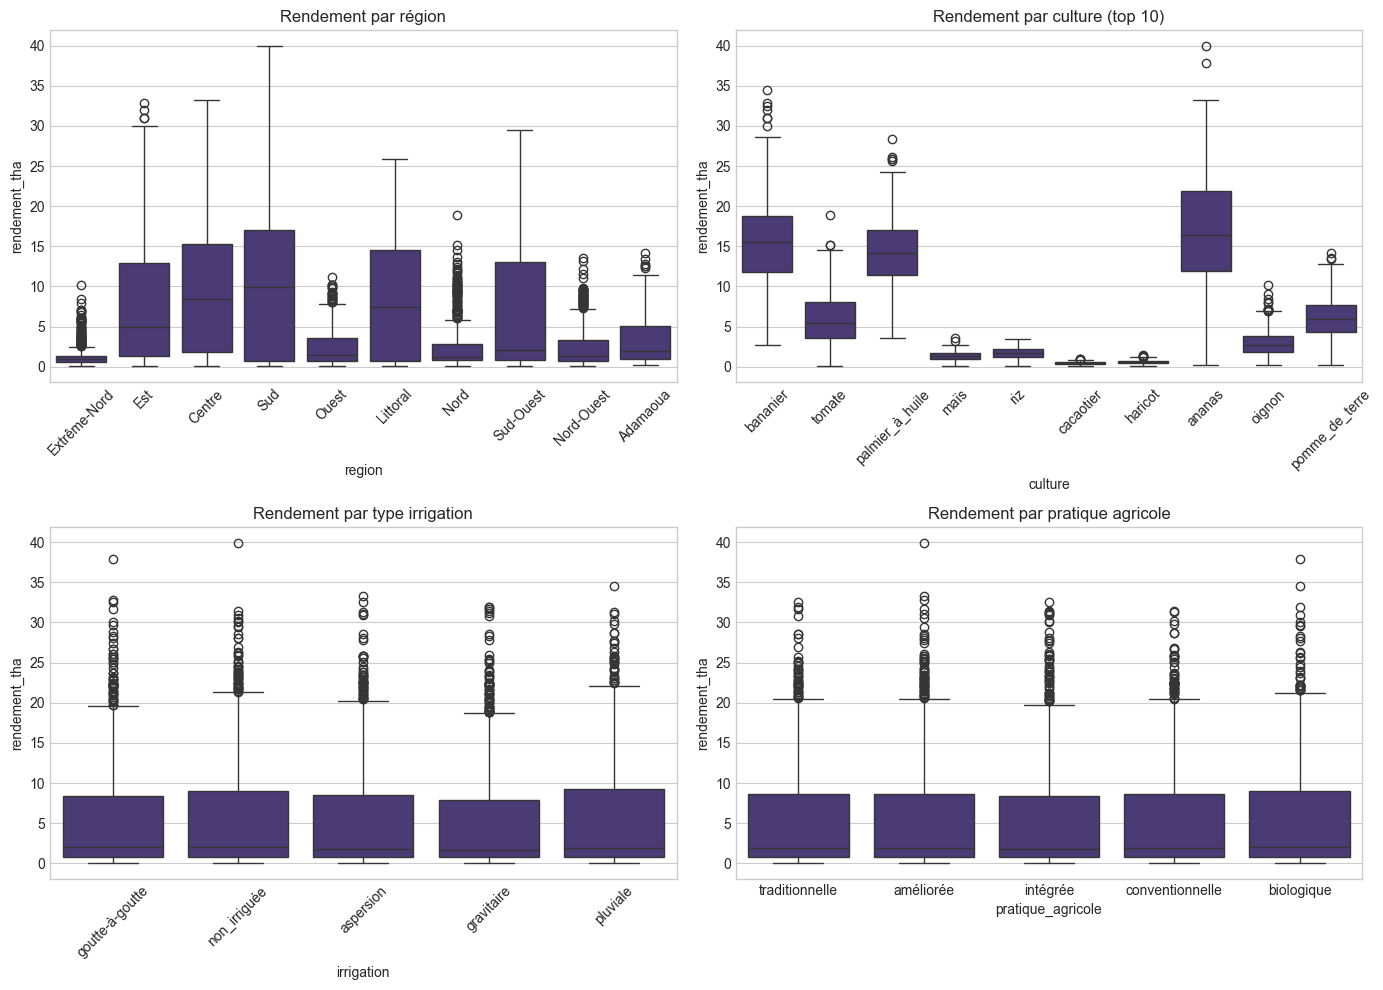

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='region', y='rendement_tha', ax=axes[0, 0])
axes[0, 0].set_title('Rendement par région')
axes[0, 0].tick_params(axis='x', rotation=45)

top_cultures = df['culture'].value_counts().head(10).index
sns.boxplot(data=df[df['culture'].isin(top_cultures)], x='culture', y='rendement_tha', ax=axes[0, 1])
axes[0, 1].set_title('Rendement par culture (top 10)')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='irrigation', y='rendement_tha', ax=axes[1, 0])
axes[1, 0].set_title('Rendement par type irrigation')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='pratique_agricole', y='rendement_tha', ax=axes[1, 1])
axes[1, 1].set_title('Rendement par pratique agricole')

plt.tight_layout()
plt.savefig('../reports/figures/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Corrélations des variables numériques

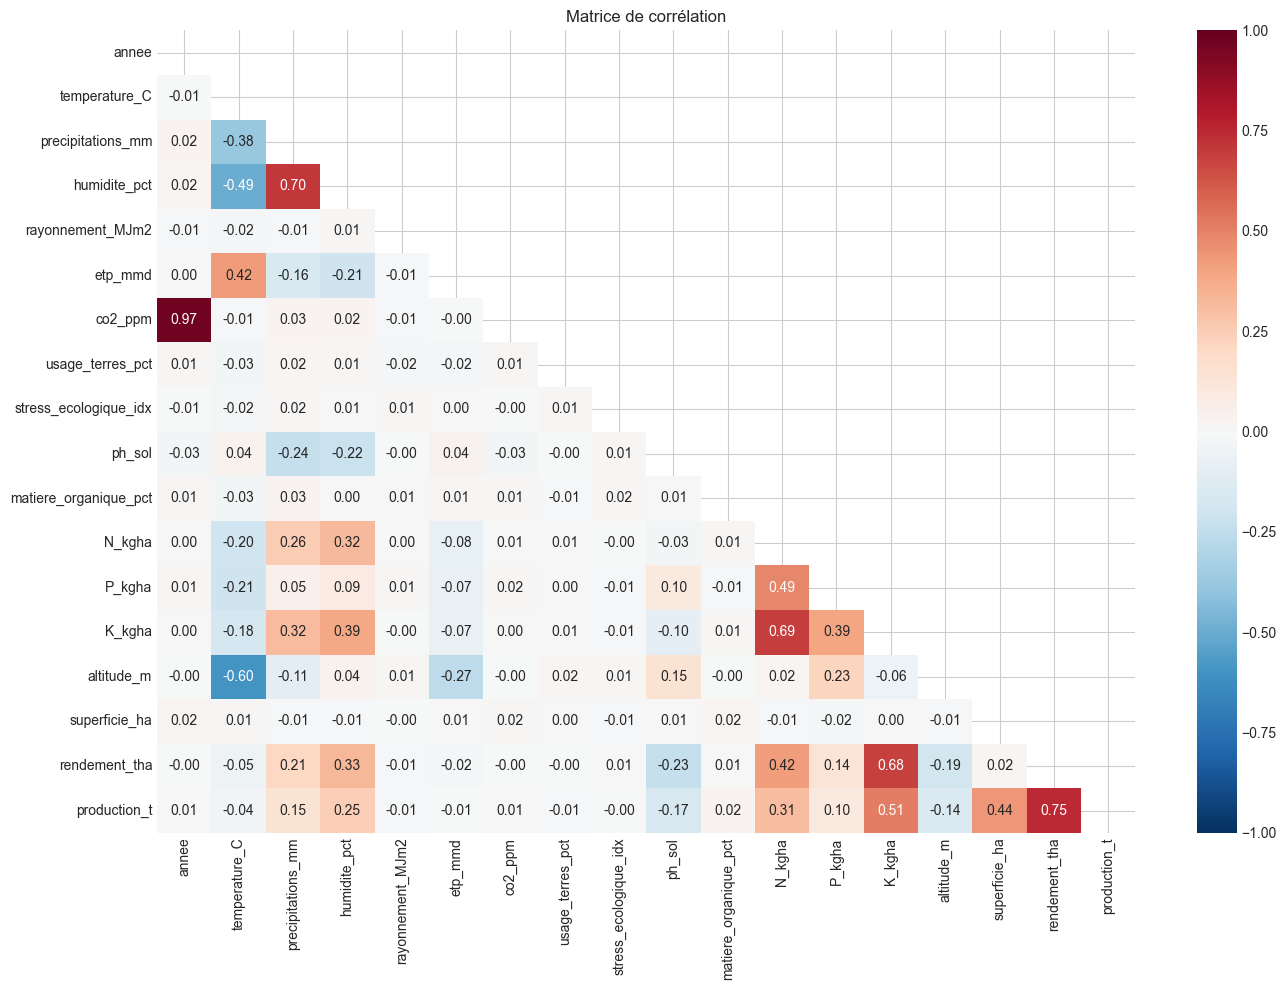

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
corr_with_target = corr_matrix['rendement_tha'].drop('rendement_tha').sort_values(ascending=False)
print("Corrélations avec le rendement :")
print(corr_with_target)

Corrélations avec le rendement :
production_t             0.747270
K_kgha                   0.683728
N_kgha                   0.420779
humidite_pct             0.332969
precipitations_mm        0.207007
P_kgha                   0.137894
superficie_ha            0.016025
stress_ecologique_idx    0.007442
matiere_organique_pct    0.006233
co2_ppm                 -0.000797
annee                   -0.001185
usage_terres_pct        -0.003205
rayonnement_MJm2        -0.012055
etp_mmd                 -0.015833
temperature_C           -0.049218
altitude_m              -0.193605
ph_sol                  -0.234965
Name: rendement_tha, dtype: float64


## 6. Relations clés avec le rendement

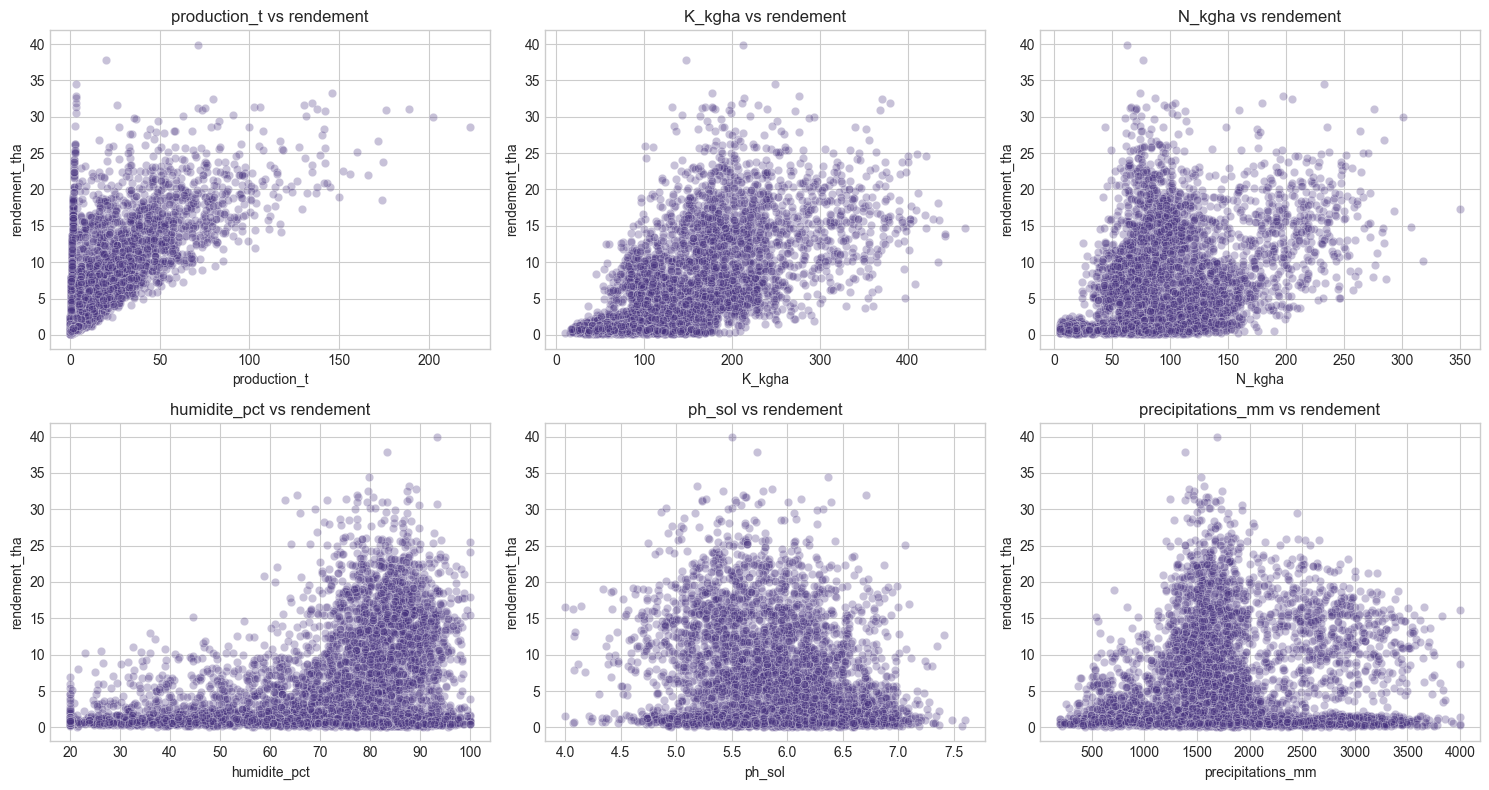

In [11]:
top_features = corr_with_target.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.scatterplot(data=df, x=feat, y='rendement_tha', alpha=0.3, ax=axes[i])
    axes[i].set_title(f'{feat} vs rendement')

plt.tight_layout()
plt.savefig('../reports/figures/scatter_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Évolution temporelle

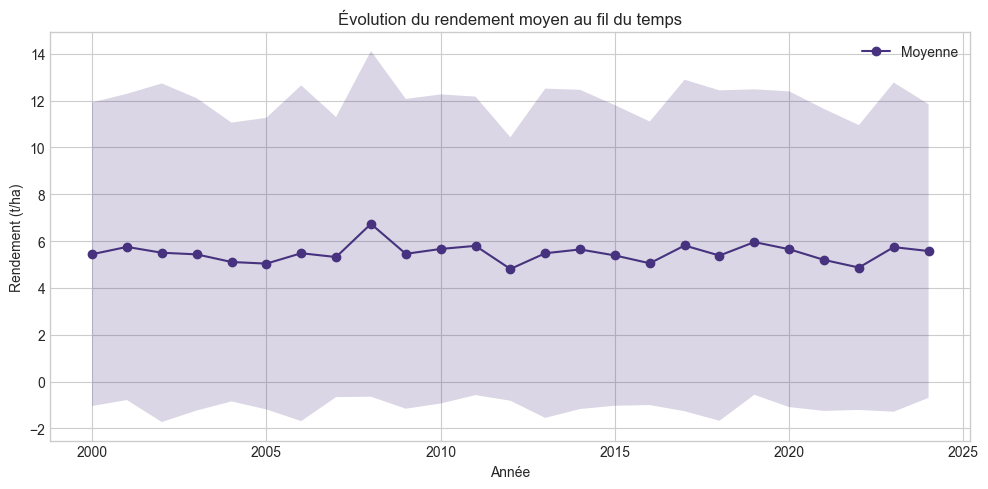

In [12]:
yearly = df.groupby('annee')['rendement_tha'].agg(['mean', 'median', 'std']).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly['annee'], yearly['mean'], marker='o', label='Moyenne')
plt.fill_between(yearly['annee'], yearly['mean'] - yearly['std'], yearly['mean'] + yearly['std'], alpha=0.2)
plt.xlabel('Année')
plt.ylabel('Rendement (t/ha)')
plt.title('Évolution du rendement moyen au fil du temps')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/temporal_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusions EDA

**À remplir après exécution :**
- Distribution de la cible
- Variables les plus corrélées au rendement
- Outliers identifiés
- Stratégie de preprocessing à adopter